### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no :2

Create an “Academic performance” dataset ofstudents and perform the following operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with
them.
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be

one of the following reasons: to change the scale for better understanding of the variable, to convert a non-
linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal

distribution.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load dataset 
df = pd.read_csv("2academic_performance_raw.csv")
df.head()

,student_id,study_hours,attendance,assignment_score,exam_score,final_score
0,1,7.0,56.0,93.0,84.0,47.0
1,2,4.0,NaN,68.0,80.0,51.0
2,3,8.0,58.0,57.0,68.0,73.0
3,4,5.0,88.0,65.0,54.0,72.0
4,5,7.0,67.0,83.0,84.0,87.0


In [3]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 student_id          0
study_hours         3
attendance          3
assignment_score    3
exam_score          3
final_score         0
dtype: int64


In [4]:
# Fill missing values using mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("After Cleaning:\n", df.isnull().sum())

After Cleaning:
 student_id          0
study_hours         0
attendance          0
assignment_score    0
exam_score          0
final_score         0
dtype: int64


In [5]:
# Data summary
print("Shape:", df.shape) #show number of rows and columns
print("\nSummary:\n", df.describe())

Shape: (30, 6)

Summary:
        student_id  study_hours  attendance  assignment_score  exam_score  \
count   30.000000    30.000000   30.000000         30.000000   30.000000   
mean    15.500000     5.074074   72.555556         72.666667   67.037037   
std      8.803408     2.242627   16.052357         16.792856   16.771243   
min      1.000000     1.000000   51.000000         47.000000   40.000000   
25%      8.250000     3.250000   57.250000         57.750000   51.000000   
50%     15.500000     5.000000   72.555556         71.333333   67.037037   
75%     22.750000     7.000000   87.250000         85.500000   80.000000   
max     30.000000     9.000000   99.000000         99.000000   98.000000   

       final_score  
count    30.000000  
mean     65.833333  
std      15.911573  
min      40.000000  
25%      53.000000  
50%      66.000000  
75%      76.000000  
max      94.000000  


In [6]:
df = pd.read_csv("2academic_performance_raw.csv")

# we added some outliers to test our code
df.loc[0, 'exam_score'] = 150
df.loc[1, 'exam_score'] = 5

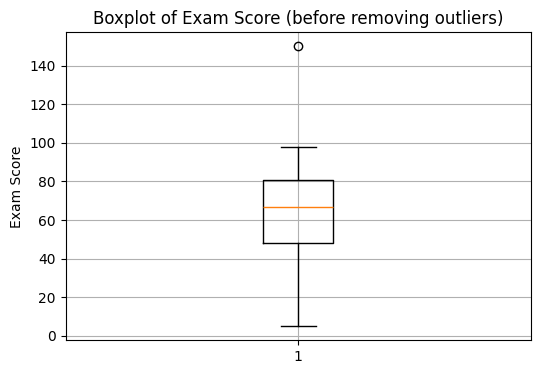

In [8]:
plt.figure(figsize=(6,4))   # important

plt.boxplot(df['exam_score'].values)   # use .values (important fix)

plt.title("Boxplot of Exam Score (before removing outliers)")
plt.ylabel("Exam Score")

plt.grid(True)

plt.show()

In [45]:
# outlier calculation  using IQR Method
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)



Lower: -0.75
Upper: 129.25


In [46]:
# Detect outliers
outliers = df[(df['exam_score'] < lower) | (df['exam_score'] > upper)]
print("Outliers:\n", outliers)

Outliers:
    student_id  study_hours  attendance  assignment_score  exam_score  \
0           1          7.0        56.0              93.0       150.0   

   final_score  
0         47.0  


In [ ]:
# Remove outliers
df_clean = df[(df['exam_score'] >= lower) & (df['exam_score'] <= upper)].copy()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (30, 6)
Cleaned Shape: (26, 6)


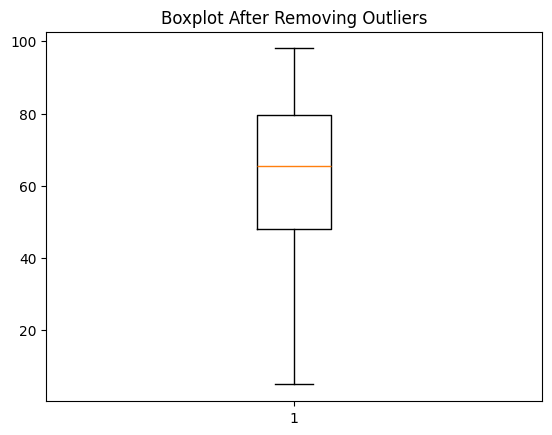

In [39]:
# Plot after cleaning
plt.boxplot(df_clean['exam_score'])
plt.title("Boxplot After Removing Outliers")
plt.show()


Data Transformation 

In [ ]:
#
print("Shape of df_clean:", df_clean.shape)
print(df_clean.head())

Shape of df_clean: (26, 7)
   student_id  study_hours  attendance  assignment_score  exam_score  \
1           2          4.0         NaN              68.0         5.0   
2           3          8.0        58.0              57.0        68.0   
3           4          5.0        88.0              65.0        54.0   
4           5          7.0        67.0              83.0        84.0   
5           6          3.0        53.0              73.0        40.0   

   final_score  exam_scaled  
1         51.0     0.000000  
2         73.0     0.677419  
3         72.0     0.526882  
4         87.0     0.849462  
5         94.0     0.376344  


In [52]:
# data scaling
from sklearn.preprocessing import MinMaxScaler

# Scaling (0–1 range)
scaler = MinMaxScaler()
df_clean['exam_scaled'] = scaler.fit_transform(df_clean[['exam_score']])
print(df_clean[['exam_score', 'exam_scaled']].head())


   exam_score  exam_scaled
1         5.0     0.000000
2        68.0     0.677419
3        54.0     0.526882
4        84.0     0.849462
5        40.0     0.376344


In [51]:
# Z-score normalization
df_clean['exam_zscore'] = (
    df_clean['exam_score'] - df_clean['exam_score'].mean()
) / df_clean['exam_score'].std()
print(df_clean['exam_zscore'].head())

1   -2.760847
2    0.212373
3   -0.448343
4    0.967476
5   -1.109058
Name: exam_zscore, dtype: float64


In [ ]:
# before log transformation
print("Before Log Transformation:")
print(df_clean['exam_score'].head())

# Log transformation (reduce skewness)
df_clean['exam_log'] = np.log(df_clean['exam_score']+1)

print("After Log Transformation:")
print(df_clean['exam_log'].head())  # here  we balanced the data by applying log transformation to reduce skewness

Before Log Transformation:
1     5.0
2    68.0
3    54.0
4    84.0
5    40.0
Name: exam_score, dtype: float64
After Log Transformation:
1    1.791759
2    4.234107
3    4.007333
4    4.442651
5    3.713572
Name: exam_log, dtype: float64


In [ ]:
# Check skewness
print("Skewness:\n", df_clean[['exam_score', 'final_score']].skew())

Skewness:
 exam_score    -0.570956
final_score   -0.072233
dtype: float64


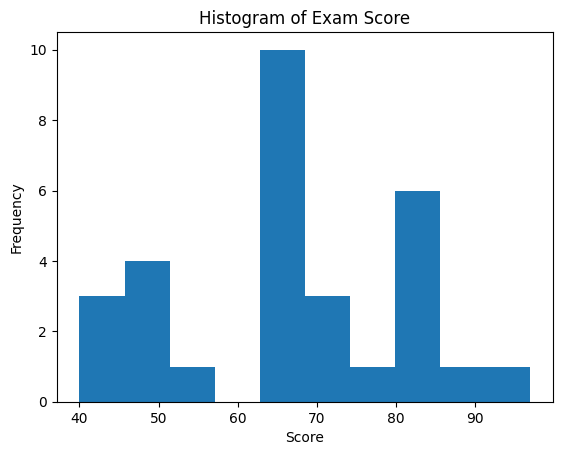

In [29]:
# Visualize distribution
plt.hist(df_clean['exam_score'], bins=10)
plt.title("Histogram of Exam Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [18]:
# final Summary statistics
print(df_clean.describe())

       student_id  study_hours  attendance  assignment_score  exam_score  \
count   30.000000    30.000000   30.000000         30.000000   30.000000   
mean    15.500000     5.166667   73.291667         73.541667   67.041667   
std      8.803408     2.078903   14.928517         16.267122   15.171387   
min      1.000000     1.000000   51.000000         47.000000   40.000000   
25%      8.250000     4.000000   59.250000         60.750000   56.250000   
50%     15.500000     5.166667   73.291667         73.541667   67.041667   
75%     22.750000     6.750000   84.750000         85.500000   79.500000   
max     30.000000     9.000000   99.000000         99.000000   97.000000   

       final_score  exam_scaled   exam_zscore   exam_log  
count    30.000000    30.000000  3.000000e+01  30.000000  
mean     65.833333     0.474415 -2.368476e-16   4.178237  
std      15.911573     0.266165  1.000000e+00   0.242769  
min      40.000000     0.000000 -1.782412e+00   3.688879  
25%      53.000000  